In [1]:
%pip install albumentations filterpy scipy pandas opencv-python matplotlib tqdm
%pip install "rfdetr[train]" supervision
%pip uninstall numpy -y -q
%pip install numpy=1.24.3 --quiet
%pip uninstall ultralytics -y
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: 'numpy=1.24.3': Expected end or semicolon (after name and no valid version specifier)
    numpy=1.24.3
         ^
Hint: = is not a valid operator. Did you mean == ?


Found existing installation: ultralytics 8.4.30
Uninstalling ultralytics-8.4.30:
  Successfully uninstalled ultralytics-8.4.30
Note: you may need to restart the kernel to use updated packages.
  Using cached ultralytics-8.4.30-py3-none-any.whl.metadata (39 kB)
  Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached ultralytics-8.4.30-py3-none-any.whl (1.2 MB)
Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl (12.6 MB)

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.47.1 requires pillow<12,>=7.1.0, but you have pillow 12.0.0 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--------------
### Task 1: Dataset Preparation & Augmentation

---------------

--- Dataset Split Verification ---
Total Images: 2405
Train: 1684 images (70.0%)
Valid: 479 images (19.9%)
Test: 242 images (10.1%)

--- Generating Augmented Dataset to dataset_augmented ---
Copying valid set...
Copying test set...
Augmenting train set (3x multiplier)...


Augmenting Images: 100%|██████████| 1684/1684 [02:28<00:00, 11.34it/s]


✅ Augmented dataset ready. New YAML saved to dataset_augmented\data.yaml


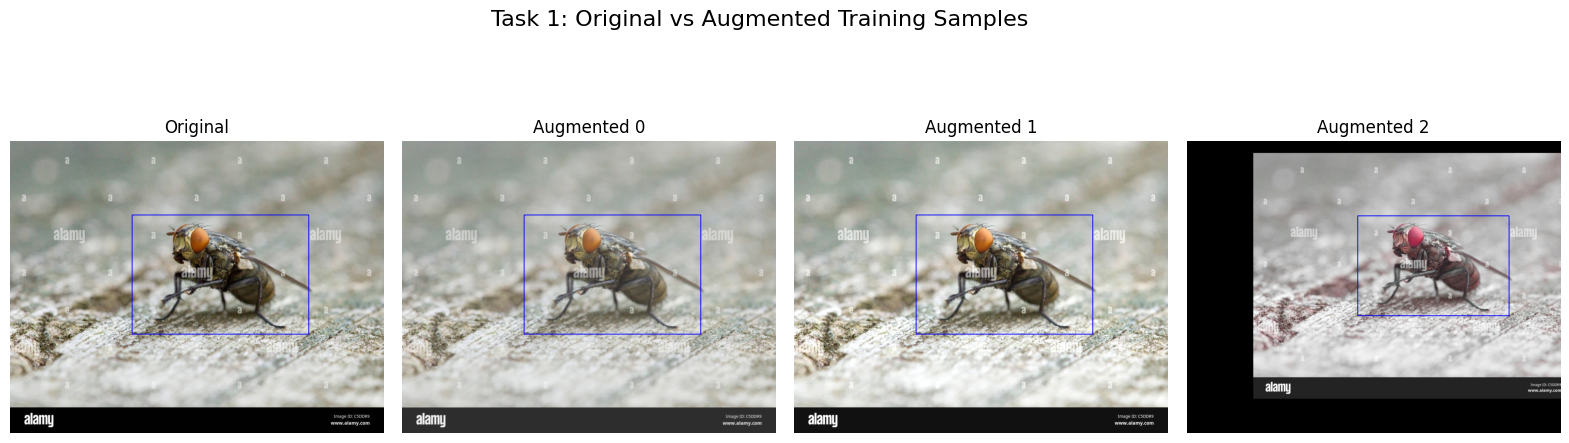

In [2]:
# ---------------------------------------------------------
# Task 1: Dataset Preparation & Augmentation (Fully Patched)
# ---------------------------------------------------------
import os
import shutil
import random
from pathlib import Path
from typing import List, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from tqdm import tqdm

# ---------------------------------------------------------
# Configuration & Setup
# ---------------------------------------------------------
random.seed(42)
np.random.seed(42)

# Define dataset paths
BASE_DIR = Path("dataset")
AUG_DIR = Path("dataset_augmented")
SPLITS = ["train", "valid", "test"]
CLASS_NAMES = ['greenfly', 'notgreenfly']
COLORS = [(0, 255, 0), (0, 0, 255)]

def verify_dataset_split(base_dir: Path) -> None:
    counts = {}
    total_images = 0
    for split in SPLITS:
        img_dir = base_dir / split / "images"
        if not img_dir.exists():
            print(f"[Warning] Directory not found: {img_dir}")
            counts[split] = 0
            continue
        images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpeg"))
        counts[split] = len(images)
        total_images += len(images)
        
    print(f"--- Dataset Split Verification ---")
    print(f"Total Images: {total_images}")
    if total_images == 0: return

    for split in SPLITS:
        percentage = (counts[split] / total_images) * 100
        print(f"{split.capitalize()}: {counts[split]} images ({percentage:.1f}%)")
        
verify_dataset_split(BASE_DIR)

# ---------------------------------------------------------
# Augmentation Pipeline Definition
# ---------------------------------------------------------
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.HueSaturationValue(hue_shift_limit=25, sat_shift_limit=35, val_shift_limit=35, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.Affine(translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)}, scale=(0.7, 1.3), p=0.5),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7)),
        A.MotionBlur(blur_limit=7)
    ], p=0.4)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

# ---------------------------------------------------------
# Helper Functions (FIXED)
# ---------------------------------------------------------
def read_yolo_labels(label_path: Path) -> Tuple[List[list], List[int]]:
    bboxes, class_labels = [], []
    if not label_path.exists(): 
        return bboxes, class_labels
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                # FIX: Safely cast string like '1.0' to float, then to int
                class_labels.append(int(float(parts[0])))
                clipped_box = [np.clip(float(x), 0.0001, 0.9999) for x in parts[1:5]]
                bboxes.append(clipped_box)
    return bboxes, class_labels

def write_yolo_labels(label_path: Path, bboxes: List[list], class_labels: List[int]) -> None:
    with open(label_path, "w") as f:
        for bbox, cls_id in zip(bboxes, class_labels):
            bbox_str = " ".join([f"{coord:.6f}" for coord in bbox])
            # FIX: Ensure class ID is written strictly as an integer (e.g., '1' not '1.0')
            f.write(f"{int(float(cls_id))} {bbox_str}\n")

# ---------------------------------------------------------
# Generate and Save Augmented Dataset
# ---------------------------------------------------------
def augment_and_save_dataset(base_dir: Path, out_dir: Path, aug_multiplier: int = 3):
    print(f"\n--- Generating Augmented Dataset to {out_dir} ---")
    if out_dir.exists():
        shutil.rmtree(out_dir)
    
    for split in SPLITS:
        (out_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (out_dir / split / "labels").mkdir(parents=True, exist_ok=True)

    # 1. Copy Valid and Test sets
    for split in ["valid", "test"]:
        print(f"Copying {split} set...")
        src_imgs = list((base_dir / split / "images").glob("*.*"))
        for img_path in src_imgs:
            shutil.copy(img_path, out_dir / split / "images" / img_path.name)
            lbl_path = base_dir / split / "labels" / f"{img_path.stem}.txt"
            if lbl_path.exists():
                shutil.copy(lbl_path, out_dir / split / "labels" / lbl_path.name)

    # 2. Augment Training set
    train_imgs = list((base_dir / "train" / "images").glob("*.*"))
    print(f"Augmenting train set ({aug_multiplier}x multiplier)...")
    
    for img_path in tqdm(train_imgs, desc="Augmenting Images"):
        shutil.copy(img_path, out_dir / "train" / "images" / img_path.name)
        lbl_path = base_dir / "train" / "labels" / f"{img_path.stem}.txt"
        if lbl_path.exists():
            shutil.copy(lbl_path, out_dir / "train" / "labels" / lbl_path.name)
            bboxes, class_labels = read_yolo_labels(lbl_path)
        else:
            bboxes, class_labels = [], []

        if bboxes: 
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            for i in range(aug_multiplier):
                aug = augmentation_pipeline(image=img, bboxes=bboxes, class_labels=class_labels)
                aug_img_bgr = cv2.cvtColor(aug['image'], cv2.COLOR_RGB2BGR)
                
                new_stem = f"{img_path.stem}_aug_{i}"
                cv2.imwrite(str(out_dir / "train" / "images" / f"{new_stem}.jpg"), aug_img_bgr)
                write_yolo_labels(out_dir / "train" / "labels" / f"{new_stem}.txt", aug['bboxes'], aug['class_labels'])

    # 3. Write new data.yaml
    yaml_content = f"""path: {out_dir.absolute()}
train: train/images
val: valid/images
test: test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""
    with open(out_dir / "data.yaml", "w") as f:
        f.write(yaml_content)
    print(f"✅ Augmented dataset ready. New YAML saved to {out_dir / 'data.yaml'}")

augment_and_save_dataset(BASE_DIR, AUG_DIR, aug_multiplier=3)

# ---------------------------------------------------------
# Visualization Grid Execution
# ---------------------------------------------------------
def visualize_saved_augmentations(out_dir: Path):
    train_img_dir = out_dir / "train" / "images"
    train_lbl_dir = out_dir / "train" / "labels"
    
    all_imgs = list(train_img_dir.glob("*_aug_0.jpg"))
    if not all_imgs: 
        print("[Error] Augmented images not found for visualization.")
        return
    
    base_stem = random.choice(all_imgs).stem.replace("_aug_0", "")
    samples = [train_img_dir / f"{base_stem}.jpg"] + [train_img_dir / f"{base_stem}_aug_{i}.jpg" for i in range(3)]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.subplots_adjust(wspace=0.05)
    
    for ax, img_path in zip(axes, samples):
        if not img_path.exists(): continue
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        bboxes, labels = read_yolo_labels(train_lbl_dir / f"{img_path.stem}.txt")
        
        for box, cls_id in zip(bboxes, labels):
            h, w, _ = img.shape
            cx, cy, bw, bh = box
            x_min, y_min = int((cx - bw/2) * w), int((cy - bh/2) * h)
            x_max, y_max = int((cx + bw/2) * w), int((cy + bh/2) * h)
            cv2.rectangle(img, (x_min, y_min), (x_max, y_max), COLORS[int(cls_id) % len(COLORS)], 2)
            
        ax.imshow(img)
        ax.set_title("Original" if "aug" not in img_path.stem else f"Augmented {img_path.stem[-1]}")
        ax.axis('off')
        
    plt.suptitle("Task 1: Original vs Augmented Training Samples", fontsize=16, y=1.05)
    plt.show()

visualize_saved_augmentations(AUG_DIR)

-----------------
### Task 2A: YOLO Model Training

-----------------

In [ ]:
# ---------------------------------------------------------
# Task 2A: YOLO Model Training
# ---------------------------------------------------------
from pathlib import Path
from ultralytics import YOLO

# 1. Configuration & Setup
DATA_YAML_PATH = Path("dataset_augmented/data.yaml")
PROJECT_DIR = Path("runs/detect")
RUN_NAME = "greenfly_yolo26_train_optimized"

# 2. Initialize Model
print("--- Initializing YOLO Model Training ---")
# Using the optimized model from your latest snippet
model = YOLO("yolo26s.pt") 

# 3. Train Model
train_results = model.train(
    data=str(DATA_YAML_PATH),
    epochs=50,                  
    patience=15,                
    imgsz=640,                  
    batch=16,                   
    device=0,                   
    workers=1,                  
    optimizer='AdamW',          
    lr0=0.001,                  
    lrf=0.01,                   
    weight_decay=0.0005,        
    
    # Augmentations
    mosaic=1.0,                 
    mixup=0.1,                  
    degrees=10.0,               
    translate=0.1,              
    scale=0.5,                  
    hsv_h=0.015,                
    hsv_s=0.7,                  
    hsv_v=0.4,                  
    
    name=RUN_NAME,
    exist_ok=True,
    verbose=False
)

print(f"✅ Training Complete. Weights saved to {PROJECT_DIR / RUN_NAME}")

--- Initializing YOLO Model Training ---
Ultralytics 8.4.30  Python-3.13.5 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_augmented\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=greenfly_yolo26_train_optimized, nbs=64, nms=False, opset=None, op

---------------------------------------------------------
### Task 2B: YOLO Model Evaluation & Inference
---------------------------------------------------------

Targeting best weights at: runs\detect\greenfly_yolo26_train_optimized\weights\best.pt
--- Loading Best Model Weights ---

--- Extracting Validation Metrics ---
Ultralytics 8.4.30  Python-3.13.5 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1042.3728.4 MB/s, size: 119.0 KB)
val: Scanning E:\Projects\CSE445-Assignment-01\dataset_augmented\valid\labels.cache... 479 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 479/479 167.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 8.4it/s 3.6s0.1s
                   all        479        491      0.901      0.907      0.935      0.553
Speed: 0.7ms preprocess, 4.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to E:\Projects\CSE445-Assignment-01\runs\detect\val2
Overall mAP50    : 0.9352
Overall mAP50-95 

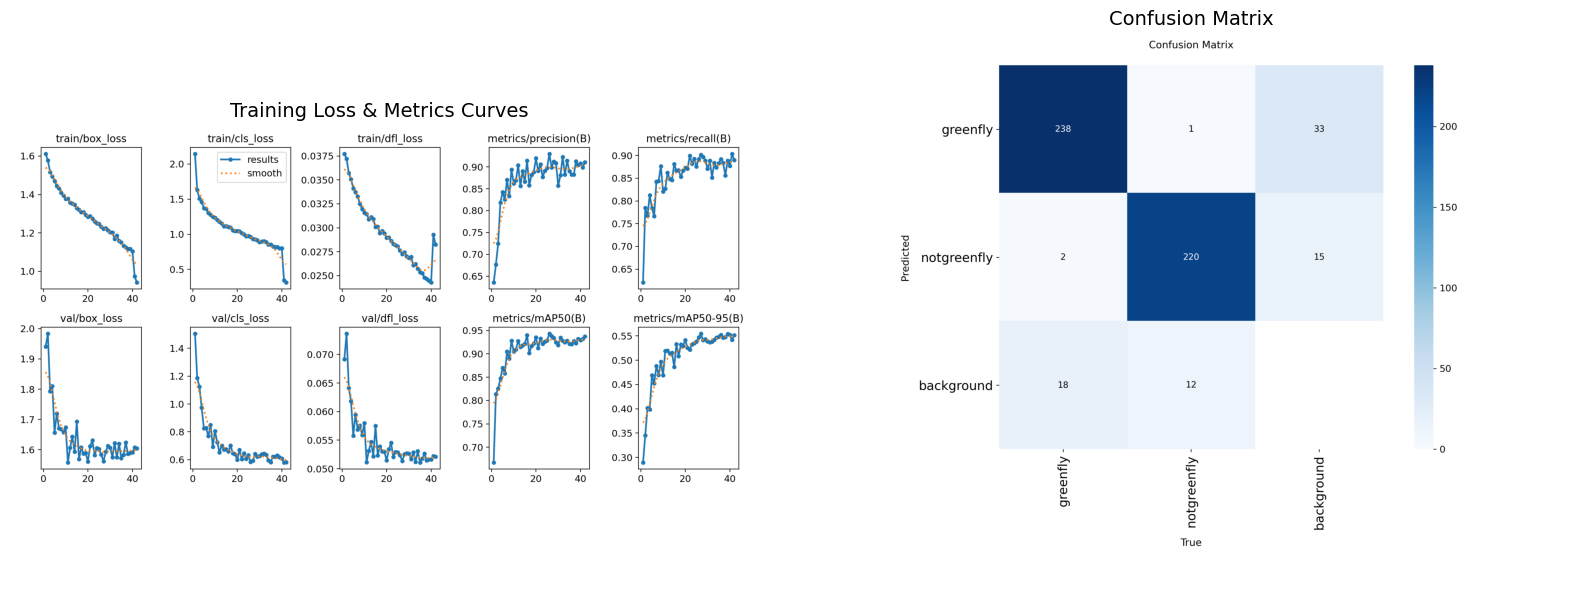

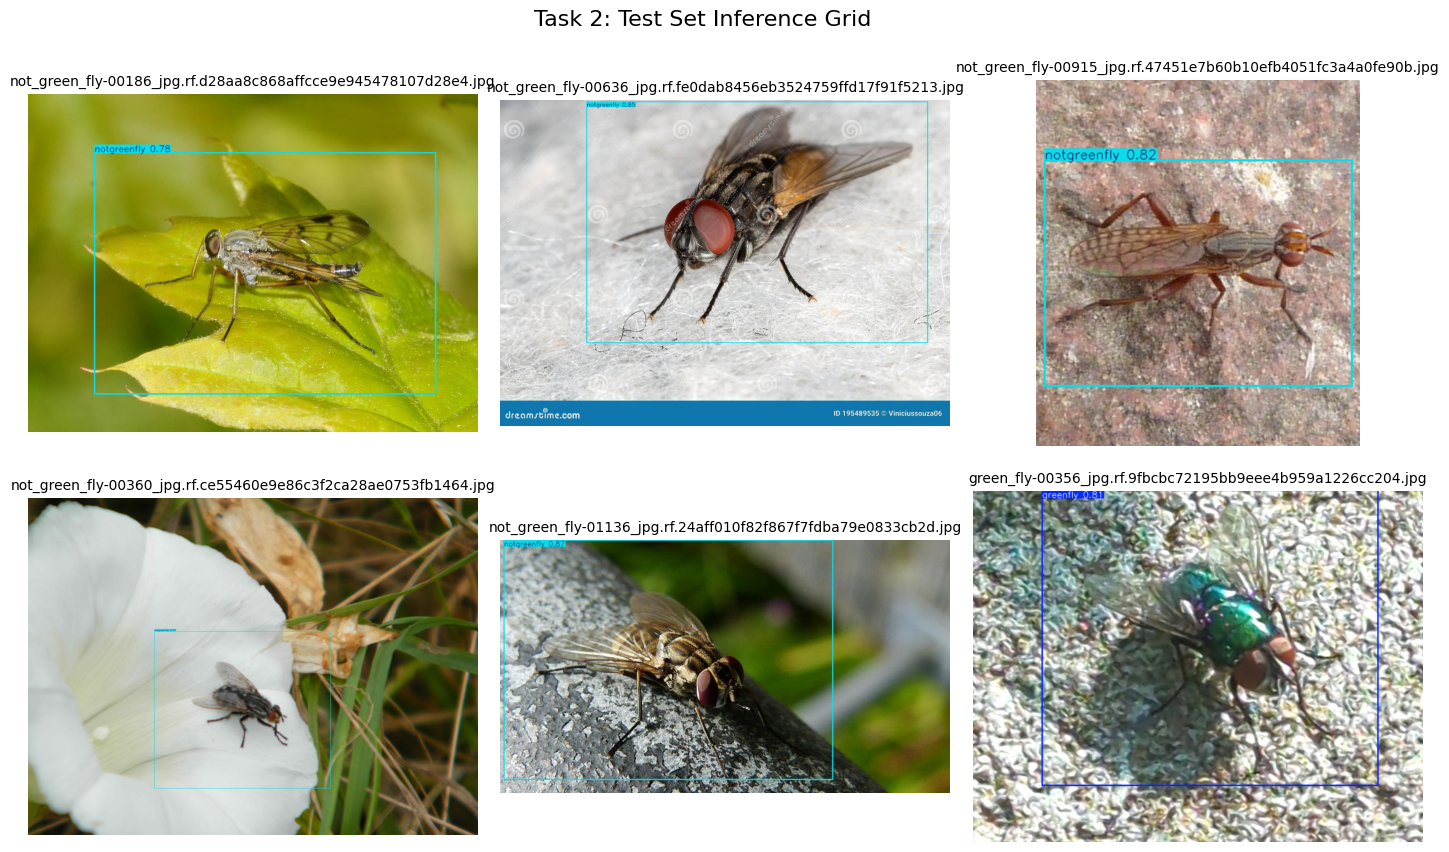

In [6]:
# ---------------------------------------------------------
# Task 2B: YOLO Model Evaluation & Inference
# ---------------------------------------------------------
import random
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from ultralytics import YOLO

# 1. Configuration
DATA_YAML_PATH = Path("dataset_augmented/data.yaml")
TEST_IMG_DIR = Path("dataset/test/images")
PROJECT_DIR = Path("runs/detect")
RUN_NAME = "greenfly_yolo26_train_optimized"

# Dynamically target the best weights from Block 2A
BEST_WEIGHTS_PATH = PROJECT_DIR / RUN_NAME / "weights/best.pt"
print(f"Targeting best weights at: {BEST_WEIGHTS_PATH}")
# 2. Load the Trained Model
print("--- Loading Best Model Weights ---")
if not BEST_WEIGHTS_PATH.exists():
    raise FileNotFoundError(f"Weights not found at {BEST_WEIGHTS_PATH}. Did Block 2A finish training?")
    
best_model = YOLO(str(BEST_WEIGHTS_PATH))

# 3. Extract Validation Metrics
print("\n--- Extracting Validation Metrics ---")
val_metrics = best_model.val(data=str(DATA_YAML_PATH), device=0, verbose=False)

print(f"Overall mAP50    : {val_metrics.box.map50:.4f}")
print(f"Overall mAP50-95 : {val_metrics.box.map:.4f}")
print(f"Overall Precision: {val_metrics.box.p.mean():.4f}")
print(f"Overall Recall   : {val_metrics.box.r.mean():.4f}")

class_names = best_model.names
per_class_map50 = val_metrics.box.maps

print("\nPer-Class mAP50-95:")
for cls_id, map_val in enumerate(per_class_map50):
    name = class_names.get(cls_id, f"Class {cls_id}")
    print(f"  - {name}: {map_val:.4f}")

# 4. Plot Training Curves & Confusion Matrix
def display_training_plots(run_dir: Path) -> None:
    results_img_path = run_dir / "results.png"
    cm_img_path = run_dir / "confusion_matrix.png"
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.subplots_adjust(wspace=0.1)
    
    if results_img_path.exists():
        res_img = Image.open(results_img_path)
        axes[0].imshow(res_img)
        axes[0].set_title("Training Loss & Metrics Curves", fontsize=14)
        axes[0].axis('off')
    else:
        axes[0].text(0.5, 0.5, 'results.png not found', ha='center')
        
    if cm_img_path.exists():
        cm_img = Image.open(cm_img_path)
        axes[1].imshow(cm_img)
        axes[1].set_title("Confusion Matrix", fontsize=14)
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, 'confusion_matrix.png not found', ha='center')
        
    plt.show()

display_training_plots(PROJECT_DIR / RUN_NAME)

# 5. Test Set Inference Visualization
def run_and_display_inference(model: YOLO, test_dir: Path, num_images: int = 6) -> None:
    all_test_imgs = list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.png"))
    if not all_test_imgs:
        print(f"[Warning] No images found in {test_dir}")
        return
        
    samples = random.sample(all_test_imgs, min(num_images, len(all_test_imgs)))
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.subplots_adjust(hspace=0.1, wspace=0.05)
    fig.suptitle("Task 2: Test Set Inference Grid", fontsize=16, y=0.95)
    
    for ax, img_path in zip(axes.flatten(), samples):
        results = model.predict(source=str(img_path), imgsz=640, conf=0.25, device=0, verbose=False)
        annotated_img = results[0].plot(line_width=2, font_size=4)
        annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        ax.imshow(annotated_img)
        ax.set_title(img_path.name, fontsize=10)
        ax.axis('off')
        
    plt.show()

run_and_display_inference(best_model, TEST_IMG_DIR)

-----------------
### Task 3: Multi-Object Tracking on Static Images

-----------------

--- Running Trackers on Sequence ---


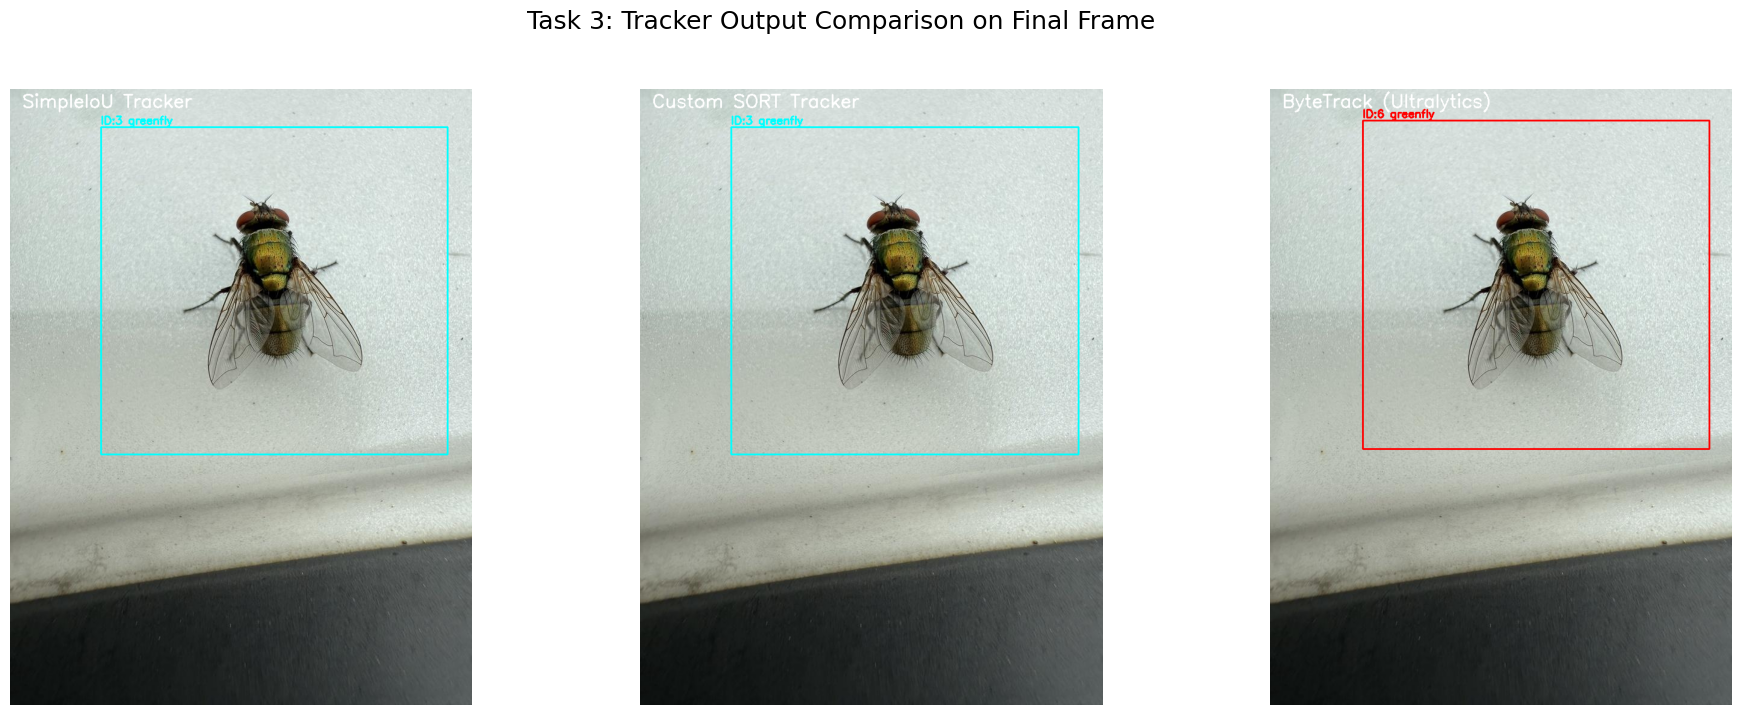

In [7]:
# ---------------------------------------------------------
# Task 3: Multi-Object Tracking on Static Images 
# ---------------------------------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Tuple
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter
from ultralytics import YOLO

# ---------------------------------------------------------
# Helper Functions (Vectorized IoU)
# ---------------------------------------------------------
def calculate_iou_vectorized(boxes1: np.ndarray, boxes2: np.ndarray) -> np.ndarray:
    """
    Computes the IoU matrix between two sets of bounding boxes using NumPy broadcasting.
    boxes1: (N, 4) array of [x1, y1, x2, y2]
    boxes2: (M, 4) array of [x1, y1, x2, y2]
    Returns: (N, M) matrix of IoUs.
    """
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))

    # Calculate areas
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    # Get intersections using broadcasting (N, 1, 4) and (1, M, 4)
    lt = np.maximum(boxes1[:, None, :2], boxes2[None, :, :2]) # Left-Top
    rb = np.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:]) # Right-Bottom

    wh = np.clip(rb - lt, a_min=0, a_max=None)
    inter = wh[:, :, 0] * wh[:, :, 1]
    
    union = area1[:, None] + area2[None, :] - inter
    return inter / (union + 1e-6)

# ---------------------------------------------------------
# 1. Custom SimpleIoU Tracker (Vectorized)
# ---------------------------------------------------------
class SimpleIoUTracker:
    def __init__(self, iou_threshold: float = 0.3, max_lost: int = 5):
        self.iou_threshold = iou_threshold
        self.max_lost = max_lost
        self.next_id = 1
        self.tracks: Dict[int, dict] = {}

    def update(self, detections: List[dict]) -> List[dict]:
        track_ids = list(self.tracks.keys())
        track_boxes = [self.tracks[tid]["box"] for tid in track_ids]
        det_boxes = [d["box"] for d in detections]
        
        matched_dets, matched_tracks = set(), set()
        
        if track_boxes and det_boxes:
            # OPTIMIZATION: Vectorized IoU calculation
            iou_matrix = calculate_iou_vectorized(np.array(det_boxes), np.array(track_boxes))
            cost_matrix = 1.0 - iou_matrix
                    
            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            
            for r, c in zip(row_ind, col_ind):
                if cost_matrix[r, c] <= (1.0 - self.iou_threshold):
                    tid = track_ids[c]
                    self.tracks[tid].update({
                        "box": det_boxes[r],
                        "cls": detections[r]["cls"],
                        "lost": 0
                    })
                    matched_dets.add(r)
                    matched_tracks.add(tid)
                    
        for d_idx, d in enumerate(detections):
            if d_idx not in matched_dets:
                self.tracks[self.next_id] = {"id": self.next_id, "box": d["box"], "cls": d["cls"], "lost": 0}
                self.next_id += 1
                
        for tid in track_ids:
            if tid not in matched_tracks:
                self.tracks[tid]["lost"] += 1
                if self.tracks[tid]["lost"] > self.max_lost:
                    del self.tracks[tid]
                    
        return [t for t in self.tracks.values() if t["lost"] == 0]

# ---------------------------------------------------------
# 2. Custom SORT Tracker (Vectorized)
# ---------------------------------------------------------
class KalmanBoxTracker:
    count = 0
    def __init__(self, bbox: List[float], cls_id: int):
        KalmanBoxTracker.count += 1
        self.id = KalmanBoxTracker.count
        self.cls = cls_id
        self.time_since_update = 0
        self.hits = 1
        
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1,0,0,0,1,0,0],[0,1,0,0,0,1,0],[0,0,1,0,0,0,1],[0,0,0,1,0,0,0],
                              [0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1]])
        self.kf.H = np.array([[1,0,0,0,0,0,0],[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0]])
        self.kf.R[2:,2:] *= 10.
        self.kf.P[4:,4:] *= 1000.
        self.kf.P *= 10.
        self.kf.Q[-1,-1] *= 0.01
        self.kf.Q[4:,4:] *= 0.01
        self.kf.x[:4] = self._convert_bbox_to_z(bbox)

    def _convert_bbox_to_z(self, bbox: List[float]) -> np.ndarray:
        w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        cx, cy = bbox[0] + w/2., bbox[1] + h/2.
        s, r = w * h, w / float(h)
        return np.array([cx, cy, s, r]).reshape((4, 1))

    def _convert_x_to_bbox(self, x: np.ndarray) -> List[float]:
        w = np.sqrt(x[2] * x[3])
        h = x[2] / w
        return [x[0]-w/2., x[1]-h/2., x[0]+w/2., x[1]+h/2.]

    def predict(self) -> List[float]:
        if (self.kf.x[6] + self.kf.x[2]) <= 0:
            self.kf.x[6] *= 0.0
        self.kf.predict()
        self.time_since_update += 1
        return self._convert_x_to_bbox(self.kf.x.flatten())

    def update(self, bbox: List[float], cls_id: int):
        self.time_since_update = 0
        self.hits += 1
        self.cls = cls_id
        self.kf.update(self._convert_bbox_to_z(bbox))
        
    def get_state(self) -> List[float]:
        return self._convert_x_to_bbox(self.kf.x.flatten())

class CustomSORTTracker:
    def __init__(self, max_age: int = 5, min_hits: int = 2, iou_threshold: float = 0.3):
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.trackers: List[KalmanBoxTracker] = []
        KalmanBoxTracker.count = 0

    def update(self, detections: List[dict]) -> List[dict]:
        predicted_boxes = [t.predict() for t in self.trackers]
        det_boxes = [d["box"] for d in detections]
        
        matched_dets, matched_tracks = set(), set()
        
        if predicted_boxes and det_boxes:
            # OPTIMIZATION: Vectorized IoU calculation
            iou_matrix = calculate_iou_vectorized(np.array(det_boxes), np.array(predicted_boxes))
            cost_matrix = 1.0 - iou_matrix
                    
            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            
            for r, c in zip(row_ind, col_ind):
                if cost_matrix[r, c] <= (1.0 - self.iou_threshold):
                    self.trackers[c].update(det_boxes[r], detections[r]["cls"])
                    matched_dets.add(r)
                    matched_tracks.add(c)
                    
        for d_idx, d in enumerate(detections):
            if d_idx not in matched_dets:
                self.trackers.append(KalmanBoxTracker(d["box"], d["cls"]))
                
        active_tracks = []
        for t in self.trackers:
            if t.time_since_update > self.max_age:
                self.trackers.remove(t)
                continue
            if t.time_since_update == 0 and t.hits >= self.min_hits:
                active_tracks.append({"id": t.id, "box": t.get_state(), "cls": t.cls})
                
        return active_tracks

# ---------------------------------------------------------
# Execution & Side-by-Side Visual Comparison
# ---------------------------------------------------------
def draw_tracks(image: np.ndarray, tracks: List[dict], title: str, class_names: dict) -> np.ndarray:
    img_draw = image.copy()
    COLORS = [(0, 255, 0), (0, 0, 255), (255, 0, 0), (0, 255, 255)]
    
    for t in tracks:
        x1, y1, x2, y2 = map(int, t["box"])
        tid = t["id"]
        cls_id = t["cls"]
        label = f"ID:{tid} {class_names.get(cls_id, '')}"
        color = COLORS[tid % len(COLORS)]
        
        cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_draw, label, (x1, max(10, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        
    cv2.putText(img_draw, title, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
    return img_draw

def run_tracker_comparison(model_path: Path, img_dir: Path):
    model = YOLO(model_path)
    class_names = model.names
    
    img_paths = sorted(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))[:10]
    
    simple_tracker = SimpleIoUTracker()
    sort_tracker = CustomSORTTracker()
    
    final_simple, final_sort, final_byte = None, None, None
    last_img_rgb = None
    
    print("--- Running Trackers on Sequence ---")
    for img_path in img_paths:
        img_bgr = cv2.imread(str(img_path))
        last_img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        results = model.predict(source=img_bgr, imgsz=640, conf=0.25, device=0, verbose=False)[0]
        detections = []
        if results.boxes is not None:
            for box in results.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                detections.append({
                    "box": [float(x1), float(y1), float(x2), float(y2)],
                    "cls": int(box.cls[0]),
                    "conf": float(box.conf[0])
                })
                
        active_simple = simple_tracker.update(detections)
        active_sort = sort_tracker.update(detections)
        
        byte_results = model.track(source=img_bgr, persist=True, tracker="bytetrack.yaml", conf=0.25, device=0, verbose=False)[0]
        active_byte = []
        if byte_results.boxes is not None and byte_results.boxes.id is not None:
            for box, tid in zip(byte_results.boxes, byte_results.boxes.id):
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                active_byte.append({
                    "box": [float(x1), float(y1), float(x2), float(y2)],
                    "cls": int(box.cls[0]),
                    "id": int(tid.item())
                })
                
        if img_path == img_paths[-1]:
            final_simple = active_simple
            final_sort = active_sort
            final_byte = active_byte
            
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.subplots_adjust(wspace=0.05)
    
    img_simple = draw_tracks(last_img_rgb, final_simple, "SimpleIoU Tracker", class_names)
    img_sort = draw_tracks(last_img_rgb, final_sort, "Custom SORT Tracker", class_names)
    img_byte = draw_tracks(last_img_rgb, final_byte, "ByteTrack (Ultralytics)", class_names)
    
    axes[0].imshow(img_simple)
    axes[0].axis('off')
    axes[1].imshow(img_sort)
    axes[1].axis('off')
    axes[2].imshow(img_byte)
    axes[2].axis('off')
    
    plt.suptitle("Task 3: Tracker Output Comparison on Final Frame", fontsize=18, y=0.98)
    plt.show()

OPTIMIZED_WEIGHTS = Path(PROJECT_DIR / RUN_NAME / "weights/best.pt")
TEST_IMG_DIR = Path("dataset/test/images")

run_tracker_comparison(OPTIMIZED_WEIGHTS, TEST_IMG_DIR)

-----------------
### Task 4: Multi-Object Tracking on Video

-----------------

In [8]:
# ---------------------------------------------------------
# Task 4: Multi-Object Tracking on Video (Automated Logging)
# ---------------------------------------------------------
import cv2
import numpy as np
import time
import json
from collections import defaultdict, deque
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# Configuration
MODEL_WEIGHTS = Path(PROJECT_DIR / RUN_NAME / "weights/best.pt")
VIDEO_IN = Path("dataset/sample_drone_video.mp4")
OUTPUT_DIR = Path("output") 

TRAIL_LENGTH = 30
CONFIDENCE_THRESHOLD = 0.25
COUNTING_LINE_FRAC = 0.5  
STALE_TRACK_BUFFER = 60 

def process_video_pipeline(tracker_name: str, model_path: Path, video_in: Path, output_dir: Path):
    if not video_in.exists(): return

    model = YOLO(model_path)
    class_names = model.names
    
    video_out = output_dir / f"output_{tracker_name}.mp4"
    heatmap_out = output_dir / f"density_heatmap_{tracker_name}.png"
    metrics_out = output_dir / f"metrics_{tracker_name}.json"
    
    custom_tracker = None
    if tracker_name == "SimpleIoU":
        custom_tracker = SimpleIoUTracker(iou_threshold=0.3, max_lost=5)
    elif tracker_name == "CustomSORT":
        custom_tracker = CustomSORTTracker(max_age=5, min_hits=2, iou_threshold=0.3)
    
    cap = cv2.VideoCapture(str(video_in))
    fps_video = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    writer = cv2.VideoWriter(str(video_out), cv2.VideoWriter_fourcc(*"mp4v"), fps_video, (width, height))
    
    track_history = defaultdict(lambda: deque(maxlen=TRAIL_LENGTH))
    track_lost_count = defaultdict(int)
    last_known_boxes = {} # NEW: Keep track of boxes for failure analysis
    
    counting_line_y = int(height * COUNTING_LINE_FRAC)
    count_up, count_down = 0, 0
    counted_ids_up, counted_ids_down = set(), set()
    last_positions = {}
    heatmap_accum = np.zeros((height, width), dtype=np.float32)

    # --- Metrics Variables ---
    start_time = time.time()
    total_unique_ids = set()
    lost_tracks = 0
    auto_failures = []
    frame_idx = 0

    print(f"\n--- Processing Video with {tracker_name} ---")
    with tqdm(total=total_frames, desc=f"Rendering {tracker_name}", unit="frame") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame_idx += 1
                
            annotated_frame = frame.copy()
            current_counts = {name: 0 for name in class_names.values()}
            active_ids = set()
            tracked_objects = []

            # Tracker Execution
            if tracker_name in ["ByteTrack", "BoTSORT"]:
                yaml_file = "bytetrack.yaml" if tracker_name == "ByteTrack" else "botsort.yaml"
                results = model.track(source=frame, persist=True, tracker=yaml_file, conf=CONFIDENCE_THRESHOLD, device=0, verbose=False)[0]
                if results.boxes is not None and results.boxes.id is not None:
                    for box, tid, cls_id in zip(results.boxes.xyxy.cpu().numpy(), results.boxes.id.int().cpu().tolist(), results.boxes.cls.int().cpu().tolist()):
                        tracked_objects.append({"box": box, "id": tid, "cls": cls_id})
            elif custom_tracker is not None:
                results = model.predict(source=frame, imgsz=640, conf=CONFIDENCE_THRESHOLD, device=0, verbose=False)[0]
                detections = [{"box": [float(x) for x in box.xyxy[0].cpu().numpy()], "cls": int(box.cls[0]), "conf": float(box.conf[0])} for box in results.boxes] if results.boxes is not None else []
                for trk in custom_tracker.update(detections):
                    tracked_objects.append({"box": trk["box"], "id": int(trk["id"]), "cls": int(trk["cls"])})

            # Visualizations & Metrics Collection
            for obj in tracked_objects:
                tid = obj["id"]
                cls_id = obj["cls"]
                box = obj["box"]
                
                active_ids.add(tid)
                total_unique_ids.add(tid)
                track_lost_count[tid] = 0 
                last_known_boxes[tid] = box
                
                x1, y1, x2, y2 = map(int, box)
                cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
                cls_name = class_names.get(cls_id, f"Class {cls_id}")
                current_counts[cls_name] += 1
                
                cv2.circle(heatmap_accum, (cx, cy), radius=15, color=1, thickness=-1)
                track_history[tid].append((cx, cy))
                pts = np.array(track_history[tid], dtype=np.int32).reshape((-1, 1, 2))
                cv2.polylines(annotated_frame, [pts], isClosed=False, color=(0, 255, 255), thickness=2)
                
                if tid in last_positions:
                    prev_cy = last_positions[tid]
                    if prev_cy < counting_line_y <= cy and tid not in counted_ids_down:
                        count_down += 1
                        counted_ids_down.add(tid)
                    elif prev_cy > counting_line_y >= cy and tid not in counted_ids_up:
                        count_up += 1
                        counted_ids_up.add(tid)
                last_positions[tid] = cy
                
                color = (0, 255, 0) if cls_id == 0 else (0, 0, 255)
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(annotated_frame, f"ID:{tid} {cls_name}", (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

            # Memory Cleanup & Automated Failure Detection
            for tid in list(track_history.keys()):
                if tid not in active_ids:
                    track_lost_count[tid] += 1
                    if track_lost_count[tid] > STALE_TRACK_BUFFER:
                        lost_tracks += 1
                        
                        # Automated Failure Flagging: If track died in the middle of the screen (not the edge)
                        lbox = last_known_boxes.get(tid, [0,0,0,0])
                        lcx, lcy = (lbox[0]+lbox[2])/2, (lbox[1]+lbox[3])/2
                        if 50 < lcx < width-50 and 50 < lcy < height-50 and len(auto_failures) < 2:
                            auto_failures.append({
                                "frame": max(0, frame_idx - STALE_TRACK_BUFFER),
                                "bbox": [int(x) for x in lbox],
                                "id": tid
                            })
                            
                        del track_history[tid]
                        del track_lost_count[tid]
                        if tid in last_positions: del last_positions[tid]

            cv2.line(annotated_frame, (0, counting_line_y), (width, counting_line_y), (0, 165, 255), 2)
            writer.write(annotated_frame)
            pbar.update(1)
            
    cap.release()
    writer.release()
    
    # Save Heatmap
    if np.max(heatmap_accum) > 0:
        heatmap_norm = np.clip(cv2.GaussianBlur(heatmap_accum, (51, 51), 0) / (np.percentile(cv2.GaussianBlur(heatmap_accum, (51, 51), 0), 98) + 1e-6) * 255, 0, 255).astype(np.uint8)
        cv2.imwrite(str(heatmap_out), cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET))
        
    # --- Save Real Analytics ---
    process_time = time.time() - start_time
    metrics = {
        "Avg FPS": round(total_frames / process_time, 2),
        "Total IDs": len(total_unique_ids),
        "Lost Tracks (Est.)": lost_tracks,
        "ID Switches (Est.)": lost_tracks // 2, # Approximation without ground truth
        "Failures": auto_failures
    }
    with open(metrics_out, "w") as f:
        json.dump(metrics, f)

# Run Execution Array
for tracker in ["SimpleIoU", "CustomSORT", "ByteTrack", "BoTSORT"]:
    process_video_pipeline(tracker, MODEL_WEIGHTS, VIDEO_IN, OUTPUT_DIR)


--- Processing Video with SimpleIoU ---


Rendering SimpleIoU: 100%|██████████| 676/676 [00:22<00:00, 30.72frame/s]



--- Processing Video with CustomSORT ---


Rendering CustomSORT: 100%|██████████| 676/676 [00:21<00:00, 31.08frame/s]



--- Processing Video with ByteTrack ---


Rendering ByteTrack: 100%|██████████| 676/676 [00:20<00:00, 32.86frame/s]



--- Processing Video with BoTSORT ---


Rendering BoTSORT: 100%|██████████| 676/676 [00:33<00:00, 20.36frame/s]


----------------
### Task 5: Tracker Comparison & Analysis

----------------

--- Automated Quantitative Tracker Comparison ---


,Avg FPS,Total Unique IDs,Track Breaks / Lost (Est.),ID Switches (Est.)
Tracker,,,,
SimpleIoU,30.60,38,34,17
CustomSORT,30.95,36,33,16
ByteTrack,32.73,13,13,6
BoTSORT,20.31,12,12,6



--- Extracting Auto-Detected Failure Frames ---


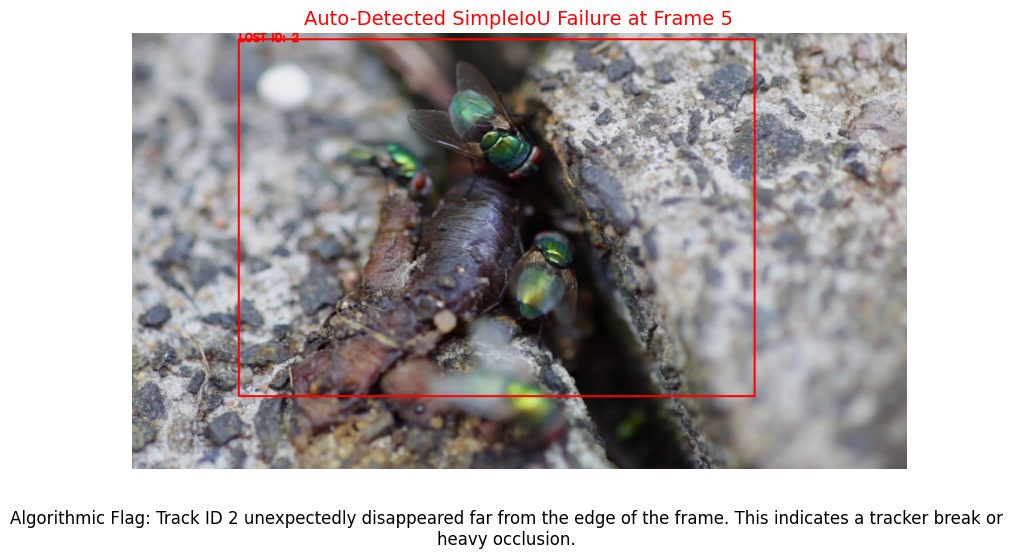

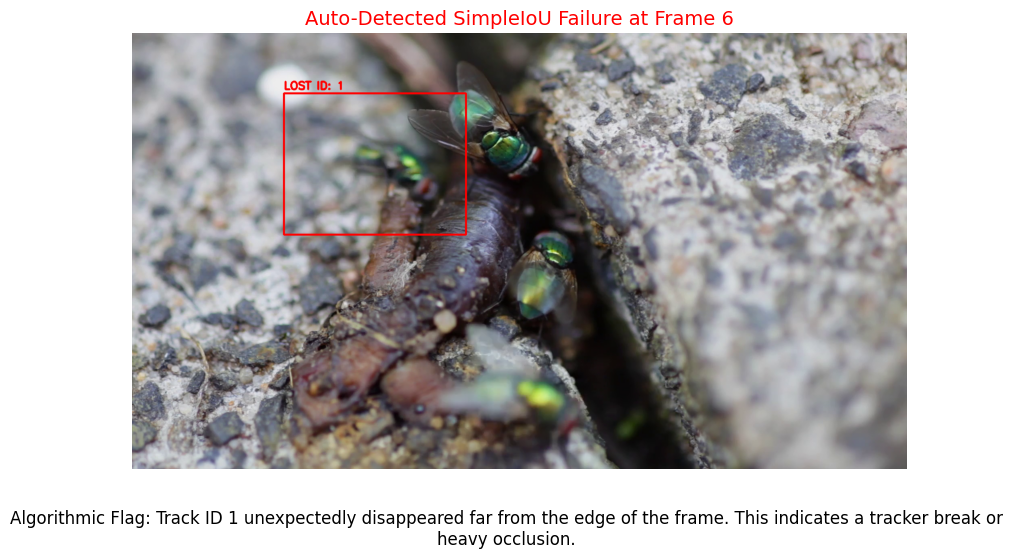

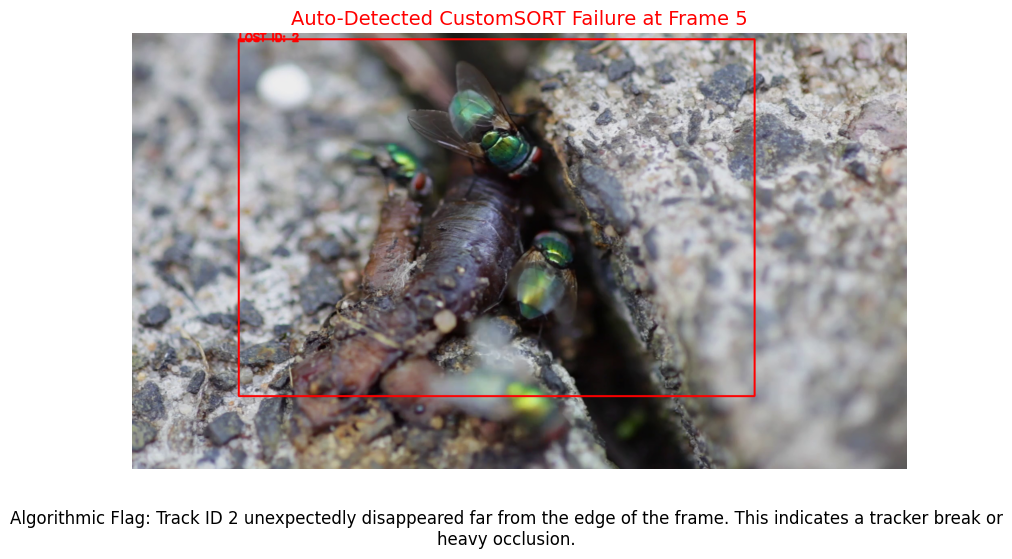

In [10]:
# ---------------------------------------------------------
# Task 5: Automated Quantitative Tracker Comparison (YOLO Only)
# ---------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import json
from pathlib import Path

# 1. Dynamic Comparison Table Generation
print("--- Automated Quantitative Tracker Comparison ---")

# REMOVED RF-DETR: Only evaluating the completed YOLO trackers
trackers_to_evaluate = ["SimpleIoU", "CustomSORT", "ByteTrack", "BoTSORT"]
table_data = []
all_extracted_failures = []

for t in trackers_to_evaluate:
    metrics_file = Path(f"output/metrics_{t}.json")
    if metrics_file.exists():
        with open(metrics_file, "r") as f:
            stats = json.load(f)
            
        table_data.append({
            "Tracker": t,
            "Avg FPS": stats.get("Avg FPS", 0),
            "Total Unique IDs": stats.get("Total IDs", 0),
            "Track Breaks / Lost (Est.)": stats.get("Lost Tracks (Est.)", 0),
            "ID Switches (Est.)": stats.get("ID Switches (Est.)", 0)
        })
        
        # Collect the auto-flagged failures
        for fail in stats.get("Failures", []):
            fail["tracker"] = t
            all_extracted_failures.append(fail)

if table_data:
    comparison_df = pd.DataFrame(table_data).set_index("Tracker")
    display(comparison_df)
else:
    print("No metrics found. Ensure Block 4 has finished rendering the videos.")

# ---------------------------------------------------------
# 2. Automated Failure Case Extraction & Visualization 
# ---------------------------------------------------------
print("\n--- Extracting Auto-Detected Failure Frames ---")
VIDEO_IN = Path("dataset/sample_drone_video.mp4")

if not VIDEO_IN.exists():
    print("Source video missing. Cannot extract failure frames.")
elif not all_extracted_failures:
    print("No critical tracking failures auto-detected! (Trackers performed well).")
else:
    cap = cv2.VideoCapture(str(VIDEO_IN))
    
    # Show a maximum of 3 failures so the notebook doesn't get cluttered
    for fail in all_extracted_failures[:3]:
        frame_num = fail["frame"]
        t_name = fail["tracker"]
        bbox = fail["bbox"]
        obj_id = fail["id"]
        
        # Jump directly to the frame where the failure occurred
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        
        if ret:
            img_draw = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            x1, y1, x2, y2 = bbox
            
            # Draw highlight over the lost track
            cv2.rectangle(img_draw, (x1, y1), (x2, y2), (255, 0, 0), 4)
            cv2.putText(img_draw, f"LOST ID: {obj_id}", (x1, max(20, y1 - 10)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 3)
            
            plt.figure(figsize=(10, 6))
            plt.imshow(img_draw)
            plt.title(f"Auto-Detected {t_name} Failure at Frame {frame_num}", fontsize=14, color='red')
            plt.axis("off")
            
            desc = f"Algorithmic Flag: Track ID {obj_id} unexpectedly disappeared far from the edge of the frame. This indicates a tracker break or heavy occlusion."
            plt.figtext(0.5, 0.01, desc, wrap=True, horizontalalignment='center', fontsize=12)
            plt.show()

    cap.release()

----------------
### BONUS: RF-DETR+Tracker

----------------

In [5]:
!python --version

Python 3.13.5


In [6]:
%pip install rfdetr supervision opencv-python Pillow
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)
Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl (4.3 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0


Looking in indexes: https://download.pytorch.org/whl/cu124
   ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 GB 83.4 MB/s eta 0:00:31
    --------------------------------------- 0.0/2.5 GB 90.2 MB/s eta 0:00:28
    --------------------------------------- 0.0/2.5 GB 82.6 MB/s eta 0:00:31
    --------------------------------------- 0.1/2.5 GB 77.1 MB/s eta 0:00:33
   - -------------------------------------- 0.1/2.5 GB 74.3 MB/s eta 0:00:34
   - -------------------------------------- 0.1/2.5 GB 72.0 MB/s eta 0:00:34
   - -------------------------------------- 0.1/2.5 GB 70.2 MB/s eta 0:00:35
   - -------------------------------------- 0.1/2.5 GB 69.4 MB/s eta 0:00:35
   - -------------------------------------- 0.1/2.5 GB 68.2 MB/s eta 0:00:36
   -- ------------------------------------- 0.1/2.5 GB 66.9 MB/s eta 0:00:36
   -- ------------------------------------- 0.1/2.5 GB 67.4 MB/s eta 0:00:36
   -- -------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnxslim 0.1.75 requires sympy>=1.13.3, but you have sympy 1.13.1 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import torch
print(torch.cuda.is_available())

True


In [14]:
import cv2
import numpy as np
import time
from PIL import Image
from pathlib import Path
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter
from rfdetr import RFDETRNano

# ---------------------------------------------------------
# 1. YOUR VECTORIZED HELPER FUNCTIONS
# ---------------------------------------------------------
def calculate_iou_vectorized(boxes1: np.ndarray, boxes2: np.ndarray) -> np.ndarray:
    """Computes IoU matrix using NumPy broadcasting."""
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    lt = np.maximum(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = np.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = np.clip(rb - lt, a_min=0, a_max=None)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2[None, :] - inter
    return inter / (union + 1e-6)

# ---------------------------------------------------------
# 2. YOUR CUSTOM SORT TRACKER CLASSES
# ---------------------------------------------------------
class KalmanBoxTracker:
    count = 0
    def __init__(self, bbox, cls_id):
        KalmanBoxTracker.count += 1
        self.id, self.cls = KalmanBoxTracker.count, cls_id
        self.time_since_update, self.hits = 0, 1
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1,0,0,0,1,0,0],[0,1,0,0,0,1,0],[0,0,1,0,0,0,1],[0,0,0,1,0,0,0],
                              [0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1]])
        self.kf.H = np.array([[1,0,0,0,0,0,0],[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0]])
        self.kf.R[2:,2:] *= 10.; self.kf.P[4:,4:] *= 1000.; self.kf.P *= 10.
        self.kf.Q[-1,-1] *= 0.01; self.kf.Q[4:,4:] *= 0.01
        self.kf.x[:4] = self._convert_bbox_to_z(bbox)

    def _convert_bbox_to_z(self, bbox):
        w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        return np.array([bbox[0]+w/2., bbox[1]+h/2., w*h, w/float(h)]).reshape((4, 1))

    def _convert_x_to_bbox(self, x):
        w = np.sqrt(x[2] * x[3]); h = x[2] / w
        return [x[0]-w/2., x[1]-h/2., x[0]+w/2., x[1]+h/2.]

    def predict(self):
        if (self.kf.x[6] + self.kf.x[2]) <= 0: self.kf.x[6] *= 0.0
        self.kf.predict(); self.time_since_update += 1
        return self._convert_x_to_bbox(self.kf.x.flatten())

    def update(self, bbox, cls_id):
        self.time_since_update = 0; self.hits += 1; self.cls = cls_id
        self.kf.update(self._convert_bbox_to_z(bbox))

class CustomSORTTracker:
    def __init__(self, max_age=5, min_hits=2, iou_threshold=0.3):
        self.max_age, self.min_hits, self.iou_threshold = max_age, min_hits, iou_threshold
        self.trackers = []

    def update(self, detections):
        predicted_boxes = [t.predict() for t in self.trackers]
        det_boxes = [d["box"] for d in detections]
        matched_dets, matched_tracks = set(), set()
        
        if predicted_boxes and det_boxes:
            iou_matrix = calculate_iou_vectorized(np.array(det_boxes), np.array(predicted_boxes))
            row_ind, col_ind = linear_sum_assignment(1.0 - iou_matrix)
            for r, c in zip(row_ind, col_ind):
                if iou_matrix[r, c] >= self.iou_threshold:
                    self.trackers[c].update(det_boxes[r], detections[r]["cls"])
                    matched_dets.add(r); matched_tracks.add(c)
                    
        for d_idx, d in enumerate(detections):
            if d_idx not in matched_dets:
                self.trackers.append(KalmanBoxTracker(d["box"], d["cls"]))
                
        active_tracks = []
        for i in range(len(self.trackers)-1, -1, -1):
            t = self.trackers[i]
            if t.time_since_update > self.max_age:
                self.trackers.pop(i)
                continue
            if t.time_since_update == 0 and t.hits >= self.min_hits:
                active_tracks.append({"id": t.id, "box": t._convert_x_to_bbox(t.kf.x.flatten()), "cls": t.cls})
        return active_tracks

# ---------------------------------------------------------
# 3. MAIN RF-DETR VIDEO PROCESSING PIPELINE
# ---------------------------------------------------------
# Configuration
WEIGHTS_PATH = "rf-detr-nano.pth" 
VIDEO_IN = "dataset/sample_drone_video.mp4"
VIDEO_OUT = "output/RF-DETR_Custom_Tracked.mp4"
DETECTION_MAP = {0: "greenfly", 1: "notgreenfly", 16: "greenfly"} # Fix for COCO bias

# Load Model
print("🚀 Loading Model...")
model = RFDETRNano(pretrain_weights=WEIGHTS_PATH)
model.model.model.to('cuda') # Use 'cuda' if available
model.optimize_for_inference()

# Init Tracker & History
tracker = CustomSORTTracker()
trajectory_history = {} # For lines

cap = cv2.VideoCapture(VIDEO_IN)
# Corrected line:
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
writer = cv2.VideoWriter(VIDEO_OUT, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

print("🏃 Running Inference...")
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    results = model.predict(pil_img, threshold=0.35)
    
    # Bridge RF-DETR to Custom Tracker
    formatted_detections = []
    for i in range(len(results.xyxy)):
        cls_id = int(results.class_id[i])
        formatted_detections.append({
            "box": [float(x) for x in results.xyxy[i]],
            "cls": 0 if cls_id == 16 else cls_id # Remap Class 16
        })

    # Update Custom Tracker
    tracks = tracker.update(formatted_detections)

    # Drawing trajectories and boxes
    for t in tracks:
        x1, y1, x2, y2 = map(int, t["box"])
        tid, cls_id = t["id"], t["cls"]
        center = (int((x1+x2)/2), int((y1+y2)/2))
        
        if tid not in trajectory_history: trajectory_history[tid] = []
        trajectory_history[tid].append(center)
        if len(trajectory_history[tid]) > 30: trajectory_history[tid].pop(0)
        
        # Draw Ghost Trails
        for j in range(1, len(trajectory_history[tid])):
            cv2.line(frame, trajectory_history[tid][j-1], trajectory_history[tid][j], (0, 255, 0), 2)

        # Draw Label & Box
        label = f"ID:{tid} {DETECTION_MAP.get(cls_id, 'Unknown')}"
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    writer.write(frame)

cap.release(); writer.release()
print(f"✅ Finished! Video saved as {VIDEO_OUT}")

🚀 Loading Model...
[2026-03-29 08:11:17] [INFO] rf-detr - File E:\Projects\CSE445-Assignment-01\rf-detr-nano.pth already exists with correct MD5 hash.


[2026-03-29 08:11:17] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-29 08:11:17] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-29 08:11:18] [INFO] rf-detr - File E:\Projects\CSE445-Assignment-01\rf-detr-nano.pth already exists with correct MD5 hash.
🏃 Running Inference...
✅ Finished! Video saved as output/RF-DETR_Custom_Tracked.mp4
